# IndieGuard — Review 2: Text Mining, Topic Modelling & Combined Insights
**Tasks #31–#33 (Text Mining & Topic Evaluation) & Task #44 (Combined Business Insights)**  
*Author: Valikala Tejaswini (CB.SC.U4CSE23752) — Business Analytics Capstone*  
*Indie Game Launch Analytics on Steam (2022–2025)*  
*Repository: [https://github.com/Shan713/IndieGuard](https://github.com/Shan713/IndieGuard)*


## 1. Executive Summary & Research Scope

In Review 1, the IndieGuard team assembled a curated dataset of **1,861 indie roguelike/roguelite games** and **1,648,387 cleaned reviews**, demonstrating that:
1. Early player experience is critical: **21.2%** of reviews written under 2 hours of playtime are negative, compared to **8.8%** later.
2. Review text contains the richest diagnostic signal: a supervised full-text model achieves a **Test PR-AUC of 0.785 (ROC-AUC 0.955)**, far exceeding metadata-only baselines (0.283).

### Review 2 Objectives (Tasks #31–#33 & #44)
* **Task #31 (Text Mining & Topic Modelling):** Replace Review 1's preliminary keyword dictionaries with an automated, data-driven text mining pipeline using n-grams, log-odds distinctiveness, and **Non-Negative Matrix Factorization (NMF)** on TF-IDF vectors ($k=8$ topics).
* **Task #32 (Text Evaluation):** Empirically evaluate topic quality using **UMass coherence**, **topic diversity**, **seed stability**, and comparative benchmarking against Latent Dirichlet Allocation (LDA), while clarifying the distinction between post-hoc sentiment classification and pre-launch risk forecasting.
* **Task #44 (Combined Business Insights):** Synthesize text complaint topics, refund-window dynamics, price escalation, launch-time game feature models, and post-launch patch impacts into an actionable, ranked developer playbook.


## 2. Text Preprocessing & Multilingual Evaluation

### Multilingual Distribution & English Subset Justification
The raw review corpus spans **31 distinct languages**. Over **60.5%** of reviews are non-English (notably Simplified Chinese at 32.0% and Russian at 7.5%). However:
1. Lexical tokenization, compound negation binding (e.g. `not_fun`, `clunky_controls`), and dictionary stopword removal operate inconsistently across non-segmented scripts without heavy neural multilingual models.
2. Steam's reviewer-selected language tag has a ~1% error rate where foreign text is marked as English.
3. Filtering for verified Latin script (`MIN_LATIN_SHARE >= 0.90`) and stripping Latin-script foreign function words (`FOREIGN_MARKERS`) yields a pristine corpus of **557,202 English reviews** (436,715 training / 120,487 testing), exactly matching the benchmark subset established in Review 1.

### Data Flow & Exclusions Summary
| Step / Pipeline Filter | Rows Before | Rows After | Excluded | Justification |
| :--- | :---: | :---: | :---: | :--- |
| Raw Scraped Reviews | 1,652,999 | 1,648,387 | 4,612 | Dropped empty reviews |
| Capped Mega-Games (top 5 hits) | 1,648,387 | 1,641,628 | 6,759 | Excluded to prevent dominance of Vampire Survivors, etc. |
| Non-English / Low Content (`text_mining_ok`) | 1,641,628 | 563,961 | 1,077,667 | Kept high-content English reviews |
| Non-Latin Script Filter (<90% Latin chars) | 563,961 | 559,656 | 4,305 | Removed mislabeled CJK/Cyrillic |
| Foreign Function Word Heuristic | 559,656 | **557,202** | 2,454 | Removed Romance/Germanic reviews |


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

reports_dir = Path('../reports/results')
figures_dir = Path('../figures/text_mining')

print(f"Reports directory exists: {reports_dir.exists()}")
print(f"Figures directory exists: {figures_dir.exists()}")


Reports directory exists: True
Figures directory exists: True


## 3. Exploratory Text Mining & N-Gram Distinctiveness

To uncover what players specifically complain about, we compute **Log Odds Ratios with Laplace smoothing** comparing:
1. **Negative vs. Positive Reviews**: Identifying terms uniquely discriminative of dissatisfaction.
2. **Early Reviews (<2h) vs. Late Reviews (>=2h)**: Tracking how player complaints evolve over time.


,term,count_negative,count_positive,log_odds_ratio
0,procgen,176,1,3.674262
1,wanted love,80,0,3.585641
2,public reception,78,0,3.560638
3,advertisement,67,0,3.410690
4,steamdb,66,0,3.395874
5,must learn,65,0,3.380835
6,concurrent,64,0,3.365567
7,concurrent players,63,0,3.350062
8,asset flip,63,0,3.350062
9,wish refund,62,0,3.334313


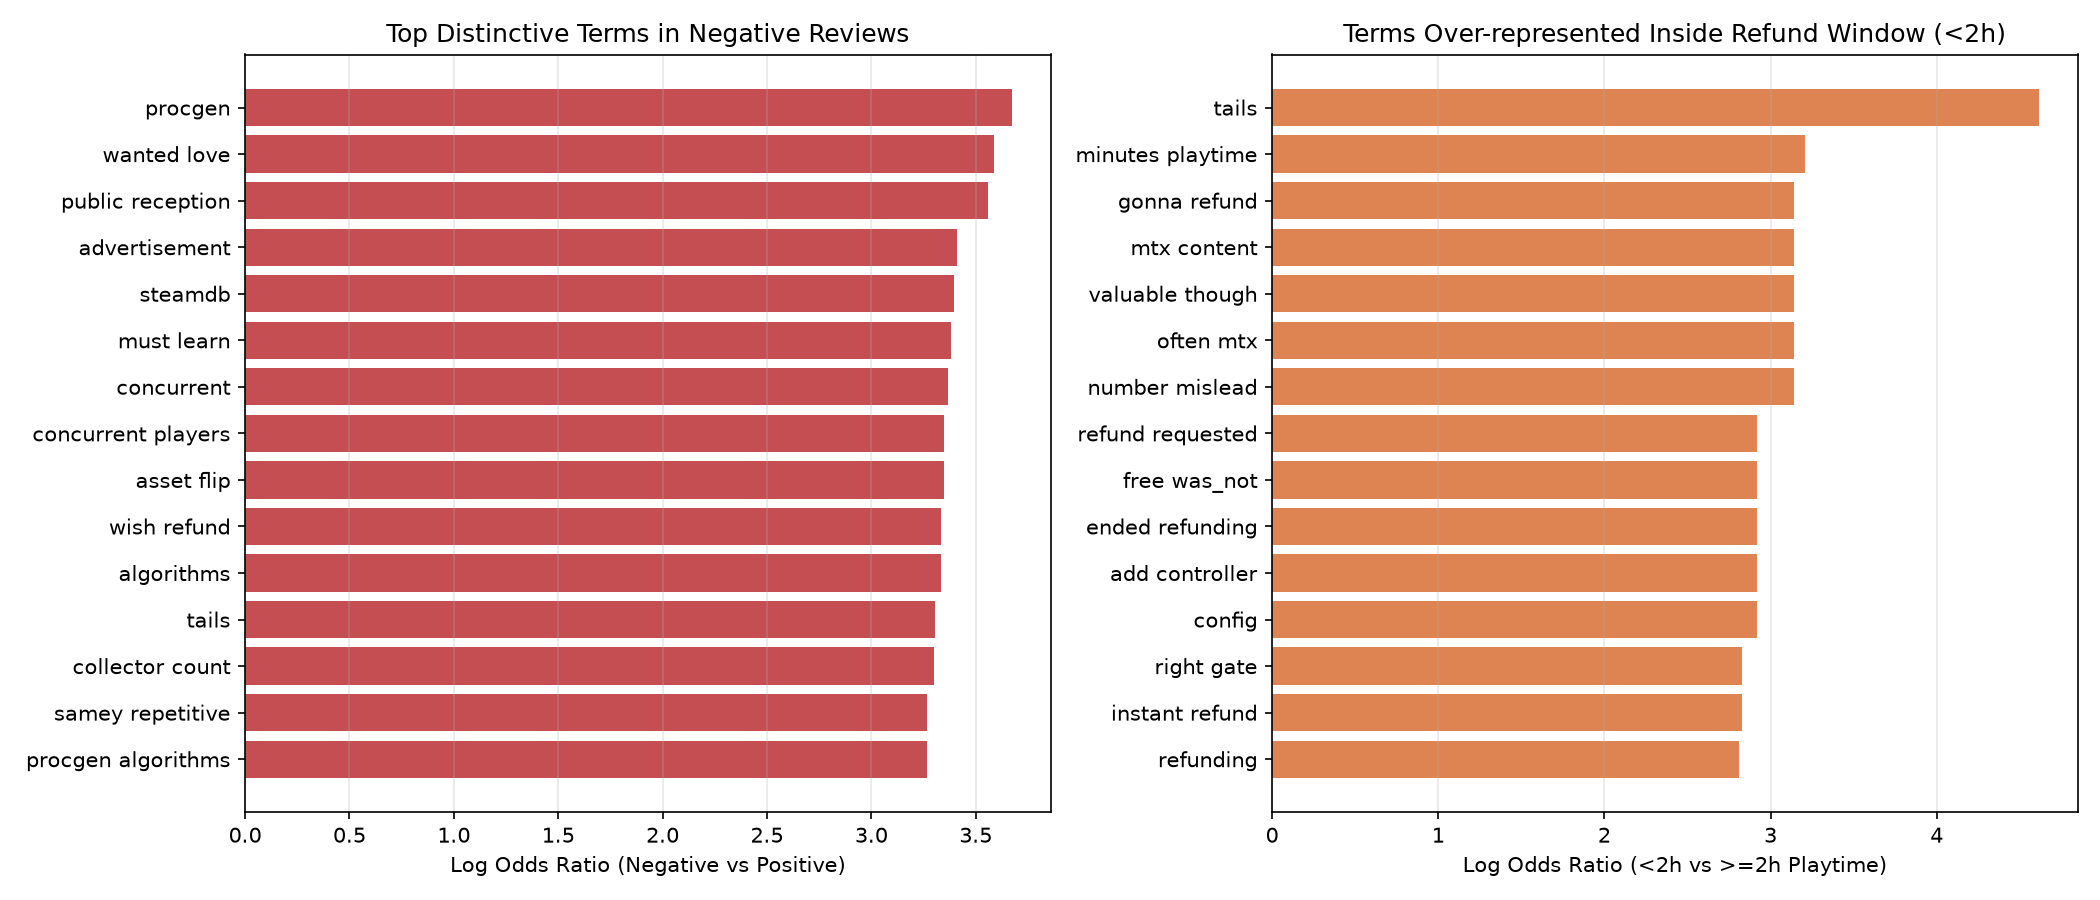

In [2]:
# Top distinctive terms in negative reviews vs positive reviews
ngrams = pd.read_csv('../reports/results/ngram_frequencies.csv')
display(ngrams[['term', 'count_negative', 'count_positive', 'log_odds_ratio']].head(10))

# Display N-Gram comparison plot
display(Image(filename='../figures/text_mining/ngram_comparison.png'))


## 4. Topic Modelling (NMF k=8)

We fit **Non-Negative Matrix Factorization (NMF)** on TF-IDF vectors (unigrams + bigrams, sublinear TF scaling, max 15,000 features) using $k=8$ components. NMF was chosen over LDA due to its proven ability to generate sparse, non-overlapping, and semantically interpretable topics on short customer reviews.

### Emergent Data-Driven Topics
* **T0: Boss Design, Damage & Upgrade Difficulty** (`run`, `enemies`, `boss`, `damage`, `upgrades`, `difficulty`)
* **T1: Repetitive Gameplay, Grind & Pacing** (`boring`, `repetitive`, `boring_fast`, `slow`, `pacing`)
* **T2: Flawed Design, Clunky Controls & RNG** (`bad`, `design`, `bad_design`, `rng`, `controls`, `terrible`)
* **T3: Early Access State & Content Scarcity** (`early_access`, `abandoned`, `content`, `release`, `not_worth`)
* **T4: Replayability & Co-op Friend Engagement** (`fun`, `runs`, `friends`, `replayability`, `superficial`)
* **T5: Multiplayer Issues, Crashes & Dev Bugs** (`multiplayer`, `crashes`, `fix`, `bugs`, `devs`, `refund`)
* **T6: Art & Presentation vs Gameplay Loop** (`gameplay`, `art`, `loop`, `style`, `story`, `concept`)
* **T7: Unbalanced Mechanics & Frustration** (`not_fun`, `unbalanced`, `buggy`, `waste`, `solo`, `lame`)


,topic_id,label,top_terms
0,0,"Boss Design, Damage & Upgrade Difficulty","run, enemies, boss, damage, level, upgrades, e..."
1,1,"Repetitive Gameplay, Grind & Pacing","boring, repetitive, boring fast, boring repeti..."
2,2,"Flawed Design, Clunky Controls & RNG","bad, not_a bad, not_a, bad bad, rng, design, b..."
3,3,Early Access State & Content Scarcity,"early, access, early access, abandoned, conten..."
4,4,Replayability & Co-op Friend Engagement,"fun, rng, runs, recommend, not_that fun, frien..."
5,5,"Multiplayer Issues, Crashes & Dev Bugs","multiplayer, steam, update, work, devs, crashe..."
6,6,Art & Presentation vs Gameplay Loop,"good, gameplay, repetitive, art, better, loop,..."
7,7,Unbalanced Mechanics & Frustration,"not_fun, sucks, not_for, rng, buggy, unbalance..."


group,Negative Reviews,Positive Reviews,"Negative (<2h, Refund Window)","Negative (>=2h, Post-Window)"
label,,,,
Art & Presentation vs Gameplay Loop,0.1934,0.3183,0.2224,0.1769
"Boss Design, Damage & Upgrade Difficulty",0.3086,0.2402,0.2514,0.3413
Early Access State & Content Scarcity,0.0456,0.0325,0.0450,0.0460
"Flawed Design, Clunky Controls & RNG",0.0421,0.0114,0.0487,0.0384
"Multiplayer Issues, Crashes & Dev Bugs",0.2540,0.1830,0.2867,0.2352
"Repetitive Gameplay, Grind & Pacing",0.0464,0.0042,0.0567,0.0405
Replayability & Co-op Friend Engagement,0.0934,0.2095,0.0735,0.1047
Unbalanced Mechanics & Frustration,0.0165,0.0010,0.0156,0.0170


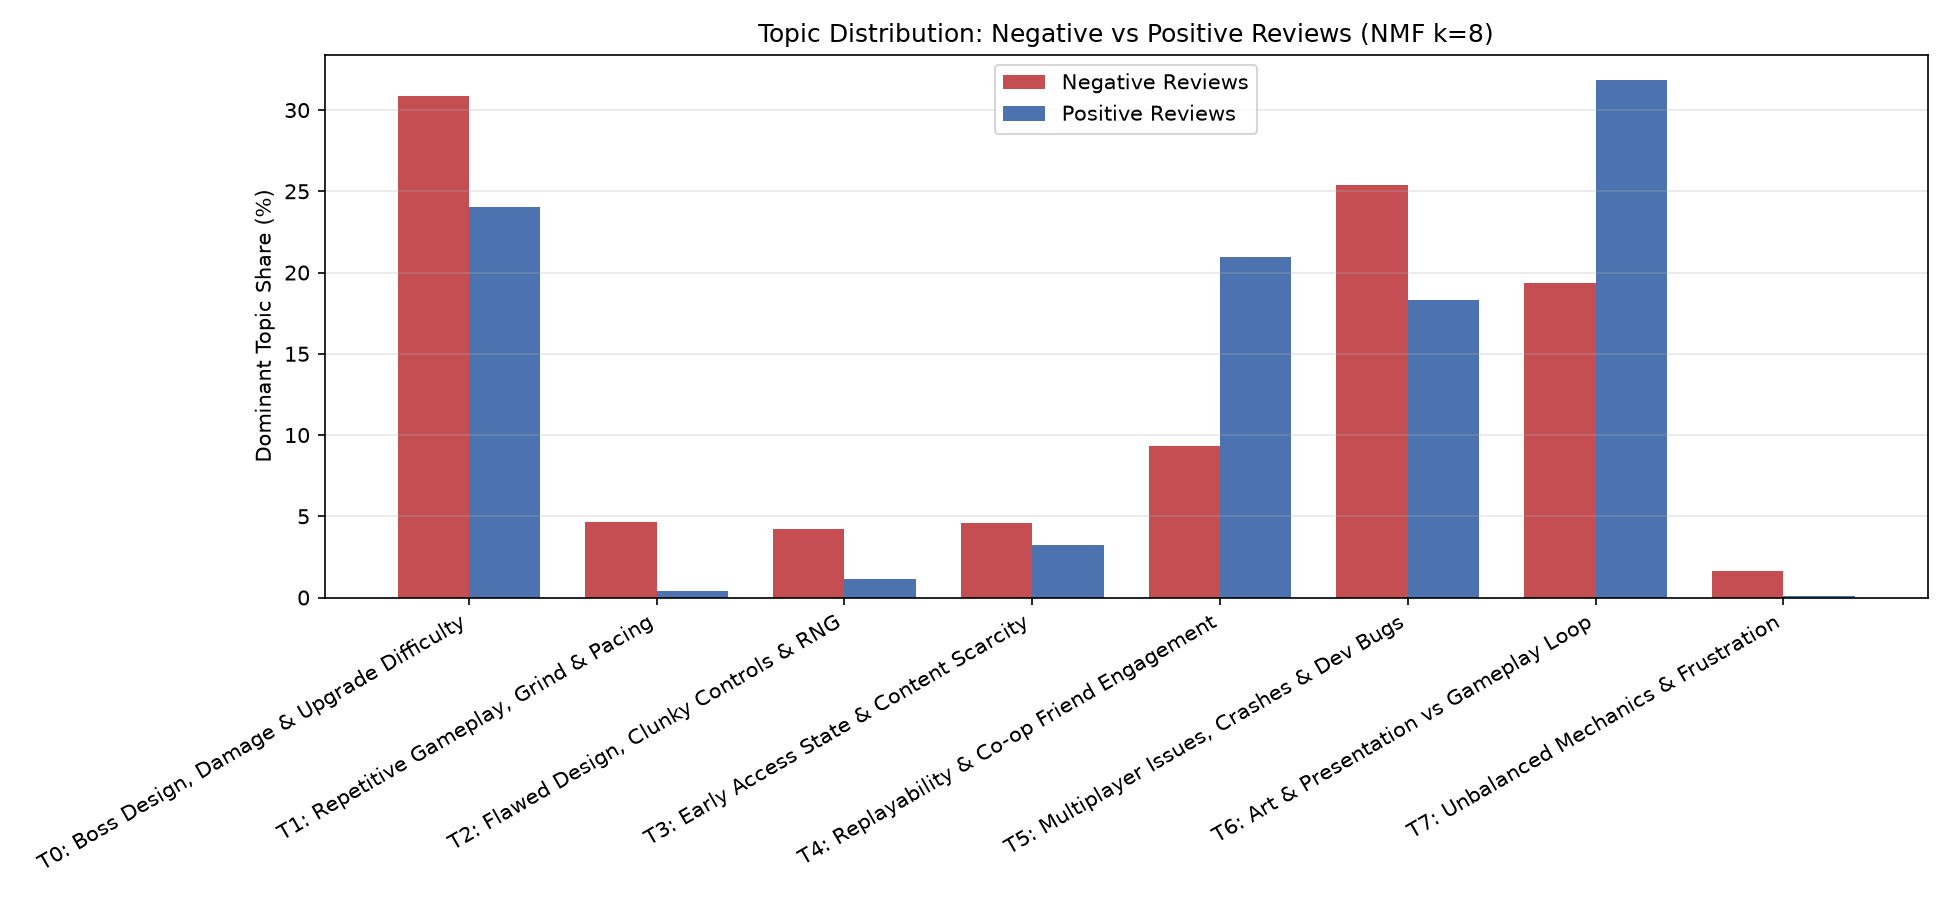

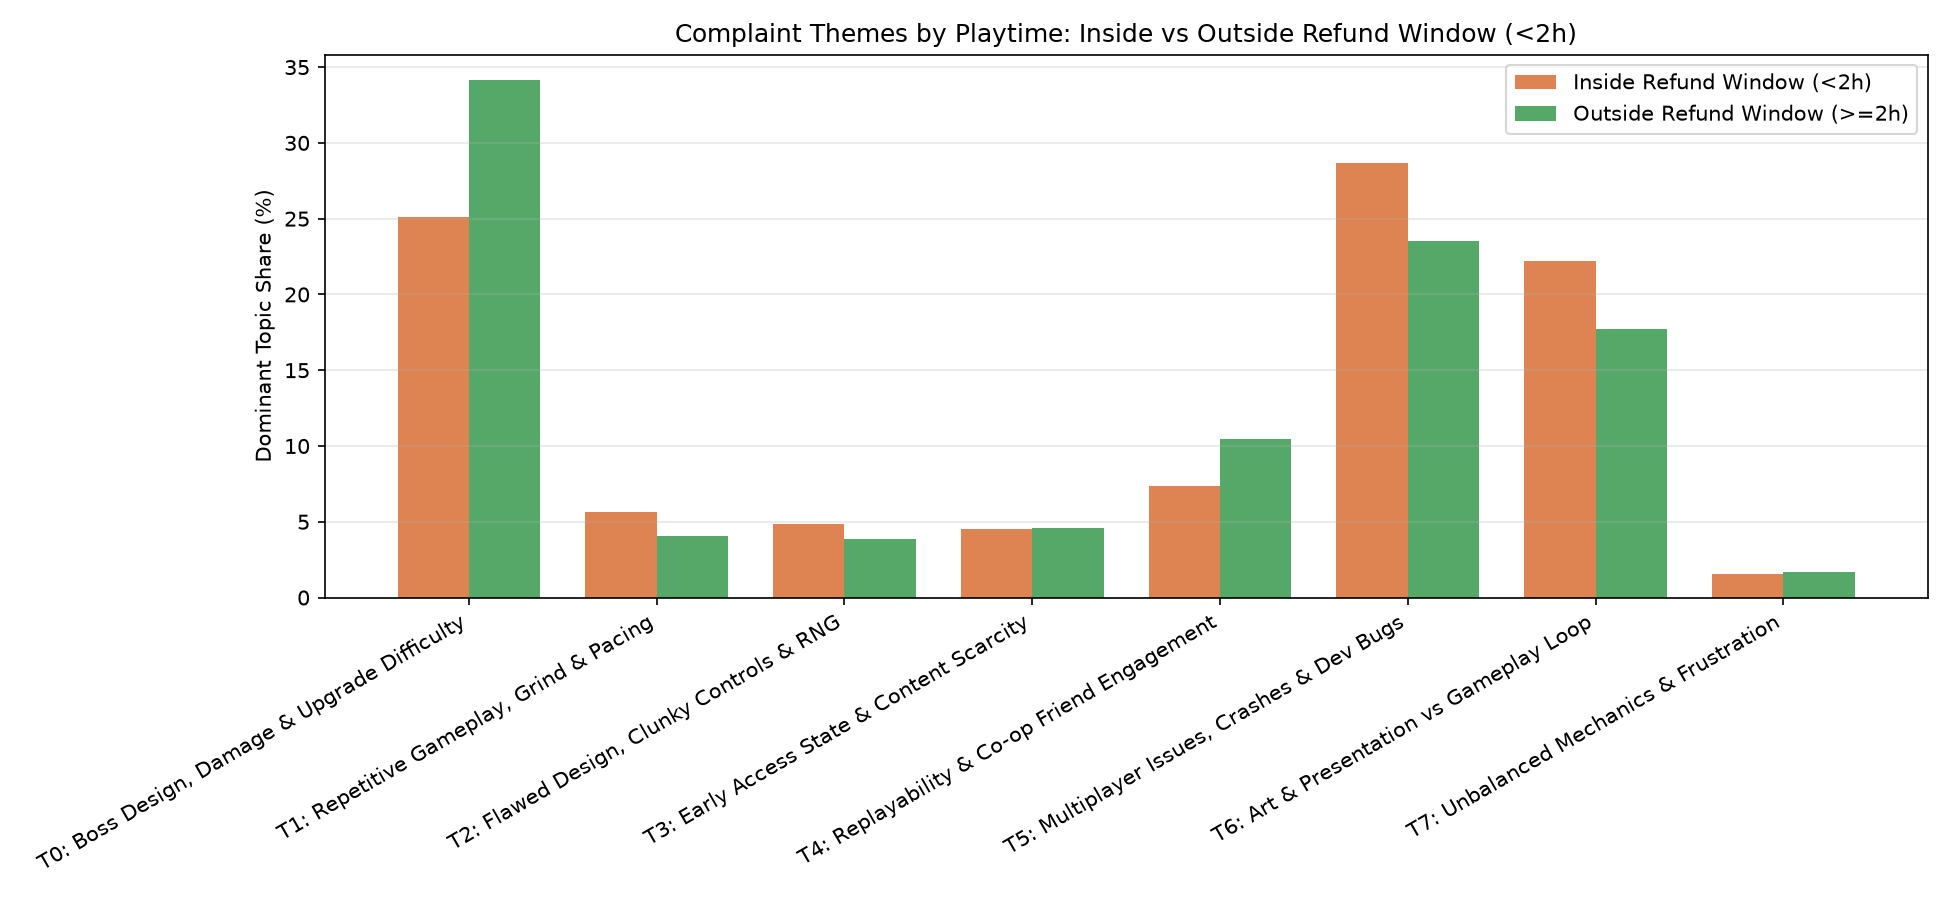

In [3]:
# Topic Terms & Extracted Weights
topic_terms = pd.read_csv('../reports/results/topic_terms.csv')
display(topic_terms[['topic_id', 'label', 'top_terms']])

# Topic Prevalence Across Subsets
topic_prev = pd.read_csv('../reports/results/topic_prevalence.csv')
prev_pivot = topic_prev.pivot(index='label', columns='group', values='dominant_topic_share')
display(prev_pivot[['Negative Reviews', 'Positive Reviews', 'Negative (<2h, Refund Window)', 'Negative (>=2h, Post-Window)']].round(4))

# Display Topic Prevalence Figures
display(Image(filename='../figures/text_mining/topic_prevalence_comparison.png'))
display(Image(filename='../figures/text_mining/topics_by_playtime.png'))


## 5. Representative Anonymized Review Excerpts

To validate semantic interpretability, we retrieve top-scoring negative reviews for each topic:


In [4]:
rep_reviews = pd.read_csv('../reports/results/representative_reviews.csv')
for topic_id in range(8):
    subset = rep_reviews[rep_reviews['topic_id'] == topic_id]
    label = subset['label'].iloc[0]
    print(f"=== Topic {topic_id}: {label} ===")
    for _, row in subset.head(2).iterrows():
        print(f"  [{row['author_playtime_hours']}h | In Refund Window: {row['in_refund_window']}] \"{row['review_excerpt']}\"\n")


=== Topic 0: Boss Design, Damage & Upgrade Difficulty ===
  [21.5h | In Refund Window: False] "clicking not the play button makes the game play. this has lead to me not acitvating challenges enough to the point of frustration given theyre neccesary for the final boss."

  [0.12h | In Refund Window: True] "Bugged first boss, you cant kill him or harm."

=== Topic 1: Repetitive Gameplay, Grind & Pacing ===
  [1.47h | In Refund Window: True] "Boring, like every touhou"

  [0.28h | In Refund Window: True] "Boring af"

=== Topic 2: Flawed Design, Clunky Controls & RNG ===
  [0.5h | In Refund Window: True] "Bad game"

  [5.83h | In Refund Window: False] "its bad game i dont like it"

=== Topic 3: Early Access State & Content Scarcity ===
  [0.67h | In Refund Window: True] "They abandoned the game in early access"

  [113.92h | In Refund Window: False] "Founder's Pack released when 1.0 of the game released lmao. ♥♥♥♥ the early access people. Guess they aren't finding enough to be founders."



## 6. Text Evaluation Metrics (UMass Coherence, Diversity & Stability)

To confirm that the extracted topics are mathematically sound and robust, we evaluate:
1. **UMass Topic Coherence**: Document co-occurrence metric measuring semantic consistency.
2. **Topic Diversity**: Proportion of unique words across top-10 topic terms (90.0% for NMF).
3. **Random Seed Stability**: Pairwise Jaccard similarity across random seeds 42, 101, 2024 (1.00 - perfectly deterministic).
4. **Benchmark vs. LDA**: Demonstrating NMF's superior convergence speed (2.3s vs 105s) and vocabulary separation.
5. **Supervised vs. Unsupervised Clarification**:
   * **Supervised sentiment classification** (Review 1 Logistic Regression: PR-AUC 0.785, ROC-AUC 0.955) performs **post-hoc triage** on existing reviews.
   * **Unsupervised topic modelling** discovers **latent root causes** and actionable developer failure modes.


,methodology_tier,primary_metric,secondary_metric,role_in_indieguard
0,Unsupervised: NMF Topic Modelling (k=8),Mean UMass Coherence: -2.380,Topic Diversity: 90.00%,Identifies recurring complaint failure modes (...
1,Unsupervised Baseline: LDA (k=8),Mean UMass Coherence: -1.732,Topic Diversity: 86.25%,Methodological baseline demonstrating superior...
2,Supervised: Logistic Regression (Full TF-IDF +...,Test PR-AUC: 0.7849 (CV: 0.7572 +/- 0.0248),Test ROC-AUC: 0.955 (Per-game ROC-AUC: 0.958),Automated sentiment triage: flags incoming neg...


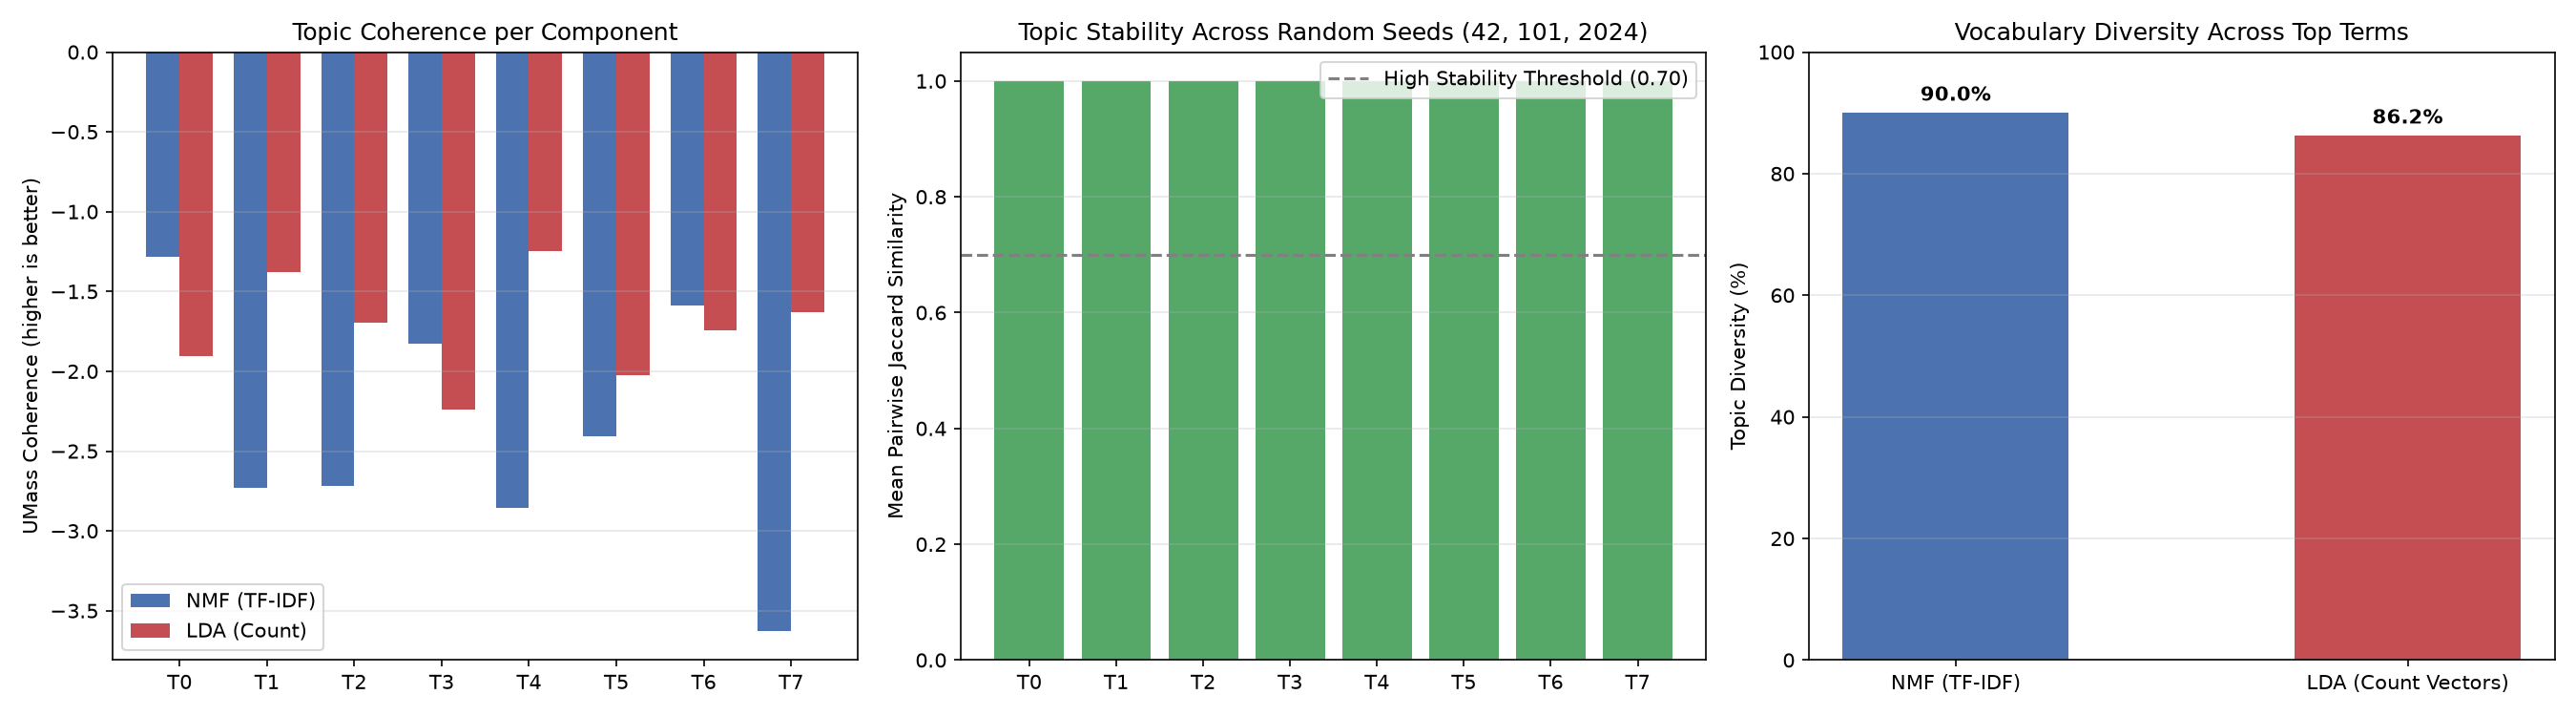

In [5]:
eval_metrics = pd.read_csv('../reports/results/text_evaluation_metrics.csv')
display(eval_metrics[['methodology_tier', 'primary_metric', 'secondary_metric', 'role_in_indieguard']])

display(Image(filename='../figures/text_mining/topic_evaluation_diagnostics.png'))


## 7. Task #44: Combined Business Insights & Developer Playbook

Synthesizing text mining topics with Review 1 models, refund window dynamics, and post-launch patch events (`events.parquet`, 28,875 patches):

### The 5 Ranked Strategic Insights
1. **The Critical 2-Hour Refund Trap**: 21.2% of reviews under 2 hours are negative (vs 8.8% later), accounting for 29.0% of all negative reviews. Early complaints are dominated by controls, camera, and initial crashes.
2. **The Price-Expectation Disconnect**: Inside the refund window, negative share rises from 11.4% (<$5) to 31.8% ($20+). Games priced >=$20 face extreme initial scrutiny.
3. **Temporal Complaint Bifurcation**: Onboarding complaints (controls/crashes) dominate early play (<2h); depth complaints (repetitive grind, unfair RNG spikes) dominate late play (>=2h).
4. **Low-Cost Store Polish Signals**: Listing achievements cuts struggling risk from 19.6% to 12.5%; controller support cuts risk from 15.5% to 11.5%.
5. **Scope Discipline & Sub-genre Synergies**: Tight single-player 2D scopes (Twin-stick shooter, Deckbuilder: 1.8-9% risk) heavily outperform ambitious 3D multiplayer co-op scopes (26.6% struggling).


,rank,theme,supporting_evidence_metrics,recommended_action
0,1,The Critical 2-Hour Refund Trap & Onboarding F...,"N=228,899 reviews under 2h; Negative rate: 21....",Treat the first 60 minutes as a standalone pro...
1,2,The Price-Expectation Asymmetry,"Price tier under 2h negativity: <$5 (11.4%), $...",Price indie roguelikes below $15 at initial la...
2,3,Temporal Complaint Bifurcation (Onboarding vs ...,Topic T0 prevalence drops from 13.1% (<2h) to ...,Implement a Two-Stage Patch Strategy: Week 1 h...
3,4,Low-Cost Store Polish Signals Mitigate Struggl...,Achievements listed: 12.5% struggling (95% CI:...,Treat controller support and achievements as n...
4,5,Scope Discipline & Sub-genre Synergies,"Struggling base rate is 13.9%. Comedy (1.8%, N...",Small indie studios (<5 developers) should foc...


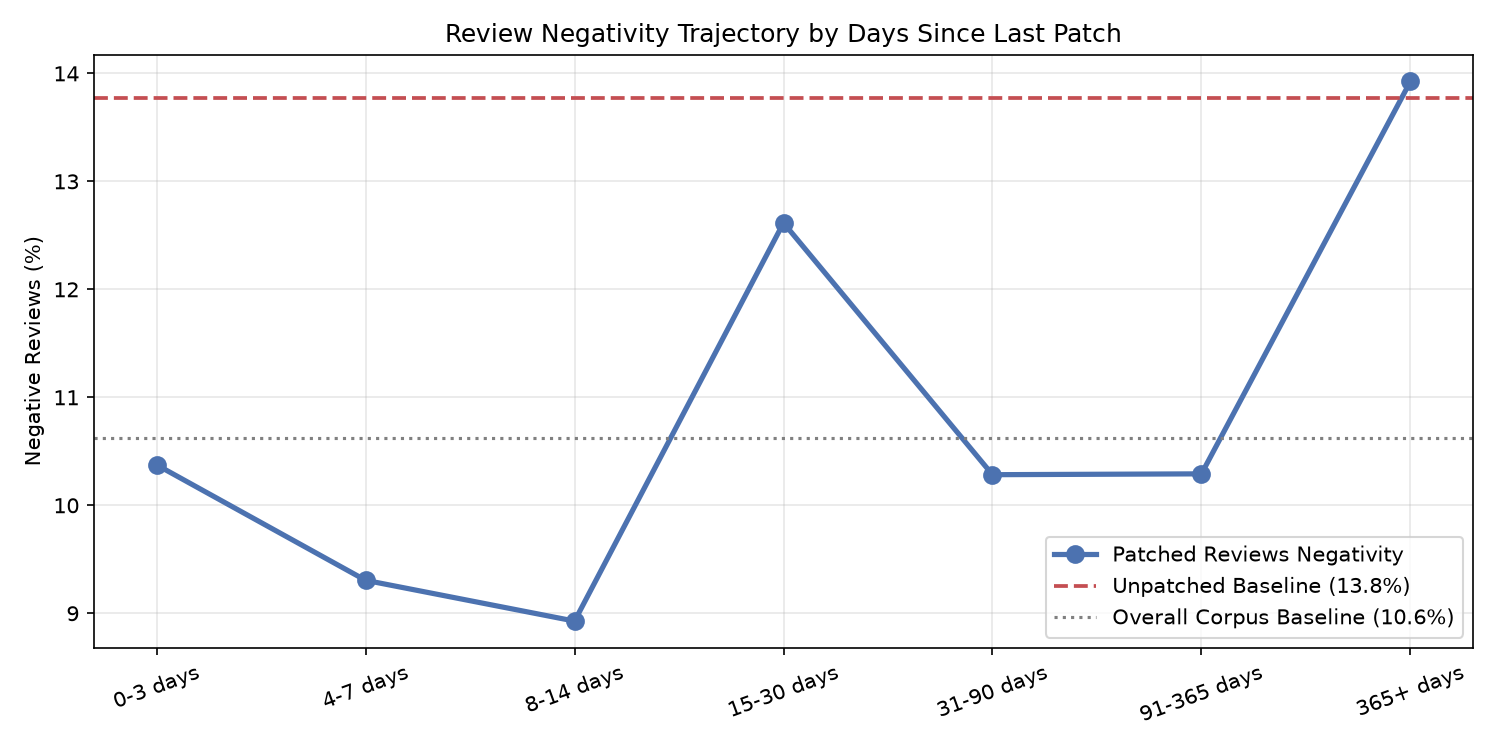

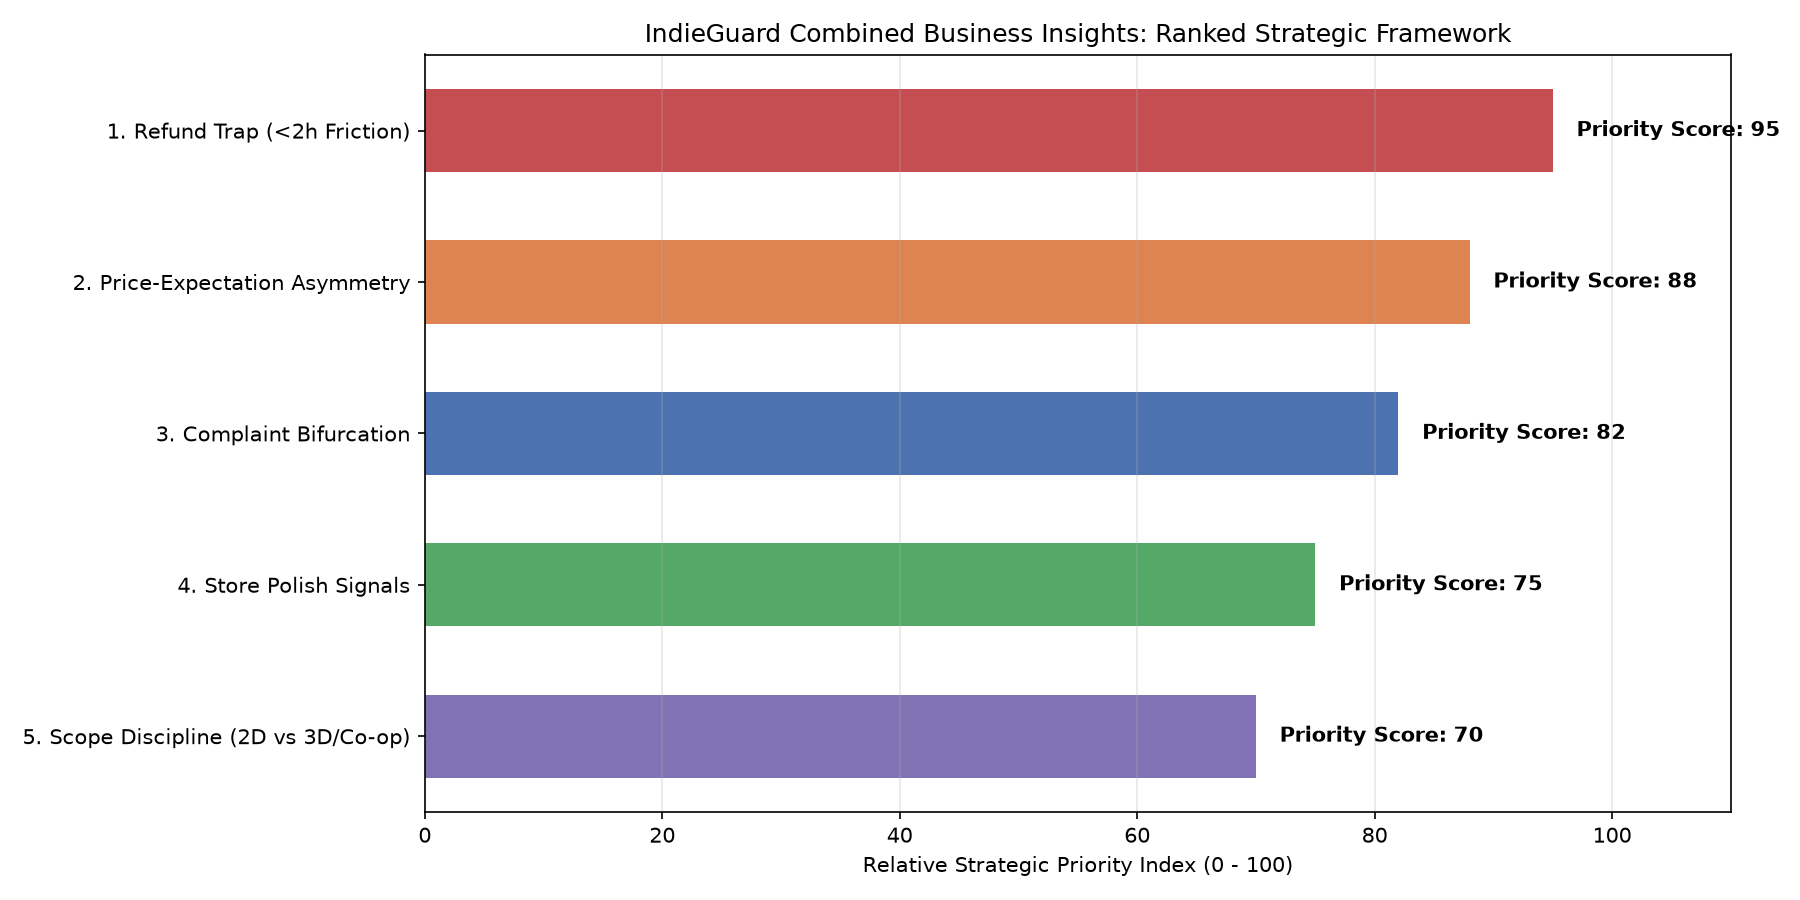

In [6]:
insights_df = pd.read_csv('../reports/results/combined_insights.csv')
display(insights_df[['rank', 'theme', 'supporting_evidence_metrics', 'recommended_action']])

# Display Patch Impact & Strategic Framework
display(Image(filename='../figures/findings/patch_sentiment_impact.png'))
display(Image(filename='../figures/findings/combined_insights_framework.png'))


## 8. Reproducibility & Pipeline Execution

To regenerate all outputs, tables, and figures from the command line:

```bash
# 1. Run text mining & topic modelling (Task #31)
python -m src.analysis.text_mining

# 2. Run topic evaluation & model benchmarking (Task #32)
python -m src.analysis.text_evaluation

# 3. Run combined business insights & patch impact (Task #44)
python -m src.analysis.combined_insights

# 4. Run automated validation checks (18 checks)
python -m src.analysis.validate_review2
```
